# **1. Introducción y contextualización**

**1.1. Contexto analítico:**

Si bien el alto índice de mortalidad durante el hundimiento del Titanic en 1912 estuvo condicionado por limitaciones técnicas y operativas (como la falta de botes salvavidas), la distribución de los sobrevivientes sugiere que el desenlace no fue puramente aleatorio. El problema a tratar en esta investigación es la exploración de posibles sesgos sociales, económicos y demográficos presentes en los datos.

En lugar de emitir conclusiones causales definitivas, nos enfocamos en evaluar el nivel de relación que tienen las características de los pasajeros con su supervivencia. Analizando tanto las variables originales como las nuevas características transformadas, se busca identificar la existencia de patrones de desigualdad estructural.

*Propósito analítico:*

Analizar la existencia de sesgos de los factores sociales o demograficos con respecto a la supervivencia de los pasajeros del Titanic.



**1.2. Pregunta de investigación:**

¿Existen sesgos sociodemográficos y económicos que presenten una relación (asociación) con el estado de supervivencia de los pasajeros del Titanic, y cómo se evidencian estos patrones al evaluar tanto las características originales como las variables transformadas?

**1.3. Objetivo del analísis:**

Identificar la relación entre los factores sociales y demográficos y la supervivencia de los pasajeros del Titanic mediante técnicas de estadística descriptiva e ingeniería de características.

---

# **2. Descripción del Dataset**




**2.1. Selección de la base de datos:**

Para este análisis se seleccionó el dataset del Titanic, derivado de la competición de Kaggle [**"Titanic - Machine Learning from Disaster"**](https://www.kaggle.com/competitions/titanic/overview). Este conjunto de datos recopila información real de los pasajeros a bordo del RMS Titanic, hundido en 1912 tras colisionar con un iceberg

El dataset contiene **891 registros** y **12 variables** relacionadas con características sociodemográficas y económicas de los pasajeros, como sexo (`Sex`), edad (`Age`), clase del boleto (`Pclass`), tarifa pagada (`Fare`) y puerto de embarque (`Embarked`), además de la variable objetivo de supervivencia (`Survived`).

Debido a la variedad y relevancia de estas variables, el conjunto de datos resulta adecuado para explorar relaciones entre las características de los pasajeros y su probabilidad de supervivencia, permitiendo identificar posibles patrones y sesgos estructurales durante el proceso de evacuación.

**2.2. Resumen de Variables**

| Variable      | Tipo                          | Descripción                                                                                                                        |
| ------------- | ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| `PassengerId` | Entero (`int64`)              | Identificador único asignado a cada pasajero.                                                                                      |
| `Survived`    | Entero binario (`int64`)      | Variable objetivo que indica si el pasajero sobrevivió (`1`) o no (`0`).                                                           |
| `Pclass`      | Entero categórico (`int64`)   | Clase socioeconómica del boleto del pasajero: primera (`1`), segunda (`2`) o tercera (`3`).                                        |
| `Name`        | Texto (`object`)              | Nombre completo del pasajero.                                                                                                      |
| `Sex`         | Categórica (`object`)         | Sexo del pasajero (`male` o `female`).                                                                                             |
| `Age`         | Numérica continua (`float64`) | Edad del pasajero en años. Presenta valores faltantes (~19.87%).                                                                   |
| `SibSp`       | Entero (`int64`)              | Número de hermanos(as) o cónyuges que viajaban junto al pasajero.                                                                  |
| `Parch`       | Entero (`int64`)              | Número de padres o hijos que viajaban junto al pasajero.                                                                           |
| `Ticket`      | Texto (`object`)              | Número o código del boleto del pasajero.                                                                                           |
| `Fare`        | Numérica continua (`float64`) | Tarifa pagada por el boleto del pasajero. Presenta valores atípicos altos.                                                         |
| `Cabin`       | Categórica (`object`)         | Número de cabina asignada al pasajero. Tiene una alta cantidad de valores faltantes (~77.10%).                                     |
| `Embarked`    | Categórica (`object`)         | Puerto de embarque del pasajero: Southampton (`S`), Cherbourg (`C`) o Queenstown (`Q`). Presenta pocos valores faltantes (~0.22%). |


Cargar Base de Datos

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
#Importación de librerías
file_path = "Titanic-Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
)

#Configuración del estilo de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#Visualización de los primeros registros
df.head(3)

/tmp/ipykernel_4047/148384536.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'titanic-dataset' dataset.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
print(f"Dimensiones del dataset: \n \n{df.shape[0]} filas × {df.shape[1]} columnas\n")


Dimensiones del dataset: 
 
891 filas × 12 columnas



In [ ]:
# Dimensiones y tipos de datos
print("Información general del dataset:\n")
df.info()

Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Estadísticas descriptivas y análisis de valores faltantes
print("-" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 60)
display(df.describe(include='all').round(2))

------------------------------------------------------------
ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.00,891.00,891.00,891,891,714.00,891.00,891.00,891,891.00,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.00,0.38,2.31,NaN,NaN,29.70,0.52,0.38,NaN,32.20,NaN,NaN
std,257.35,0.49,0.84,NaN,NaN,14.53,1.10,0.81,NaN,49.69,NaN,NaN
min,1.00,0.00,1.00,NaN,NaN,0.42,0.00,0.00,NaN,0.00,NaN,NaN
25%,223.50,0.00,2.00,NaN,NaN,20.12,0.00,0.00,NaN,7.91,NaN,NaN
50%,446.00,0.00,3.00,NaN,NaN,28.00,0.00,0.00,NaN,14.45,NaN,NaN
75%,668.50,1.00,3.00,NaN,NaN,38.00,1.00,0.00,NaN,31.00,NaN,NaN


In [ ]:
!pip install missingno

------------------------------------------------------------
ANÁLISIS DE VALORES FALTANTES
------------------------------------------------------------
          Valores Nulos  Porcentaje (%)
Cabin               687           77.10
Age                 177           19.87
Embarked              2            0.22
------------------------------------------------------------
GRÁFICA DE VALORES NO NULOS
------------------------------------------------------------


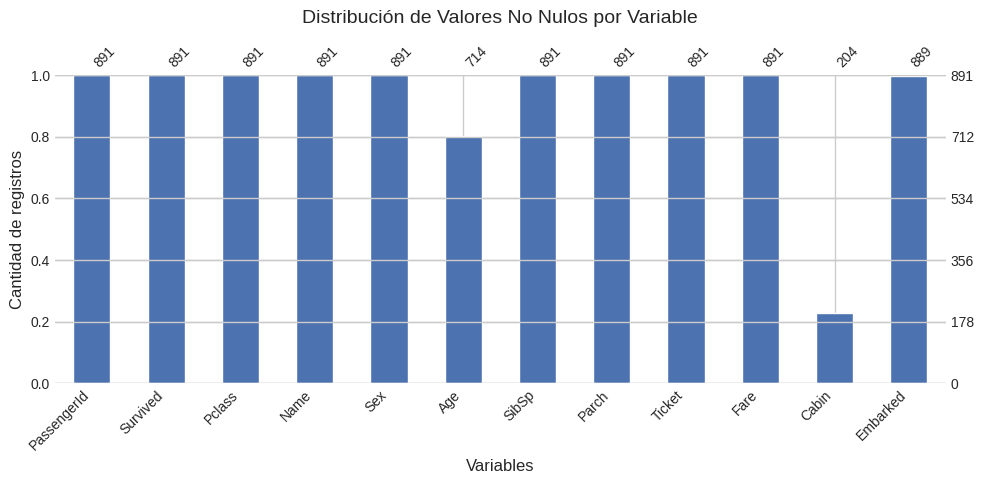

In [ ]:
print("-" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("-" * 60)
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Porcentaje (%)', ascending=False)
print(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

print("-" * 60)
print("GRÁFICA DE VALORES NO NULOS")
print("-" * 60)

import missingno as msno
import matplotlib.pyplot as plt

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')

# Crear figura
fig, ax = plt.subplots(figsize=(10, 5))

# Visualización de valores faltantes
msno.bar(
    df,
    color='#4C72B0',
    fontsize=10,
    ax=ax
)

# Personalización
ax.set_title('Distribución de Valores No Nulos por Variable', fontsize=14, pad=15)
ax.set_ylabel('Cantidad de registros')
ax.set_xlabel('Variables')

plt.tight_layout()
plt.show()


#  **3. Metodología**

El presente análisis se desarrolló bajo un enfoque cuantitativo y correlacional, utilizando técnicas estadísticas y visuales para identificar posibles relaciones entre variables sociodemográficas, económicas y la supervivencia de los pasajeros del Titanic.

Para responder a la pregunta de investigación, se implementó un flujo de trabajo analítico basado en análisis exploratorio de datos (EDA), detección de valores atípicos, imputación de datos faltantes y transformación de variables. Este proceso permitió analizar patrones de supervivencia asociados a características como el sexo, la edad, la clase social y la tarifa del boleto, sin establecer relaciones causales definitivas.


## **3.1. Analisis Exploratorio de Datos (EDA)**

- **Análisis univariado:**
Examinar la distribución individual de las variables.

- **Análisis bivariado:** Examinar las relaciones directas con la supervivencia.

- **Análisis multivariado:** Examinar las interacciones complejas entre variables.


## **3.2. Tratamiento de Datos:**
- **Detección y tratamiento de valores atípicos (Outliers):** Identificar anomalías en variables numéricas continuas para evitar distorsiones estadísticas.

- **Imputación de Datos:** Se aplicaron técnicas de imputación para tratar los valores faltantes presentes en el dataset, con el objetivo de preservar la consistencia y calidad del análisis estadístico.


- **Transformación de datos:** Se aplicaron transformaciones sobre variables numéricas y categóricas para mejorar la interpretación y el análisis de los datos.


---

# **4. Análisis Exploratorio de Datos (EDA)**


/tmp/ipykernel_19495/1426808666.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='pastel', ax=axes[1, 0])
/tmp/ipykernel_19495/1426808666.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='Set2', ax=axes[1, 1])


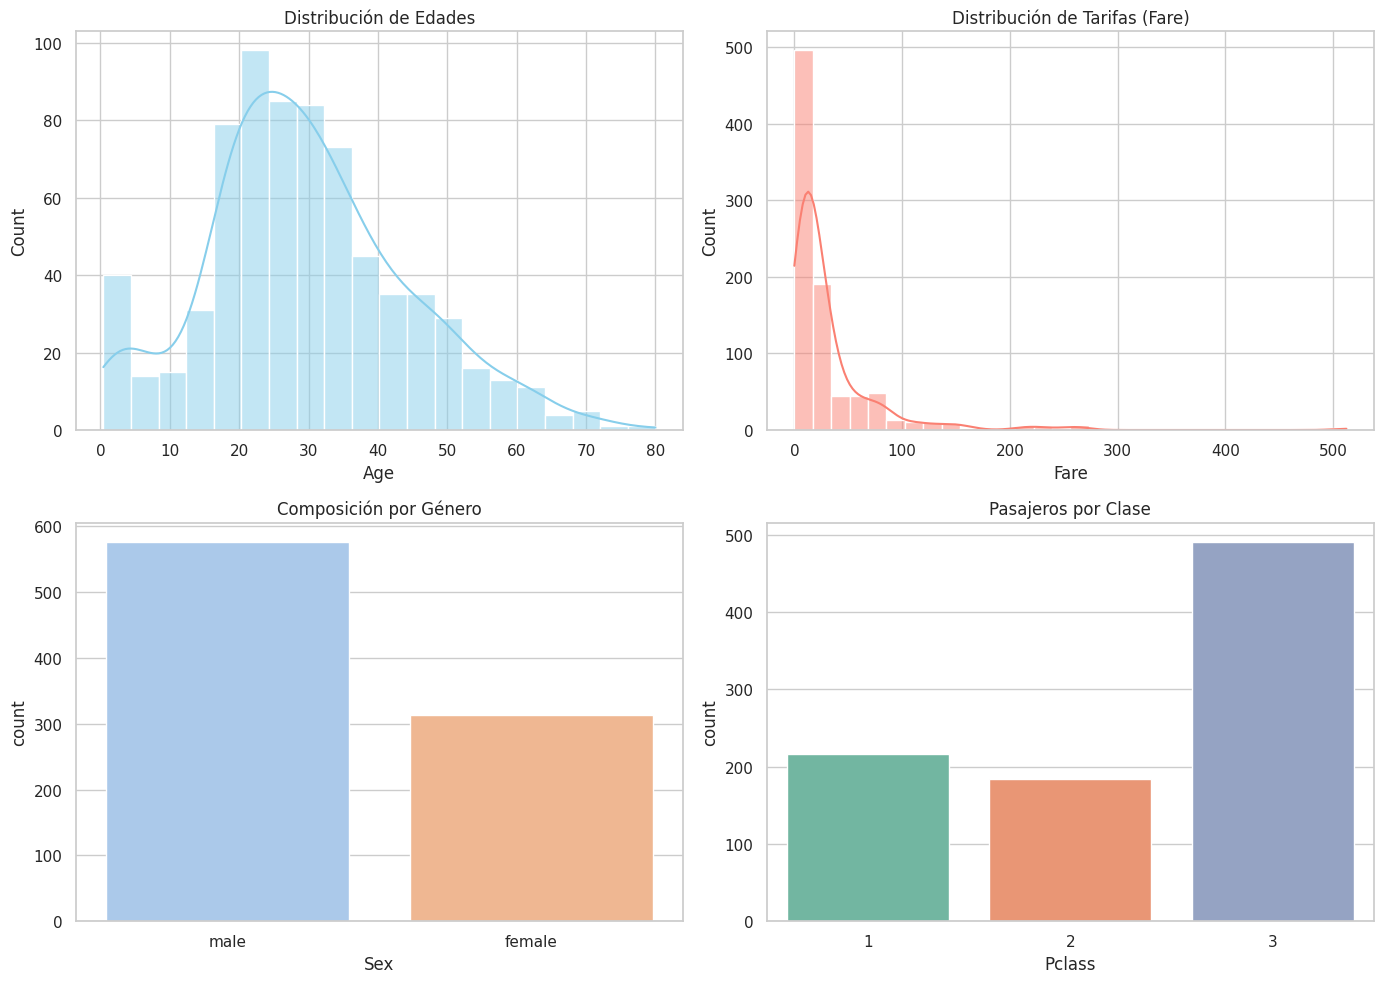

In [ ]:
#Distribución de Edad, Tarifa, Género y Clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Edades')

sns.histplot(df['Fare'], bins=30, kde=True, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Tarifas (Fare)')

sns.countplot(data=df, x='Sex', palette='pastel', ax=axes[1, 0])
axes[1, 0].set_title('Composición por Género')

sns.countplot(data=df, x='Pclass', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Pasajeros por Clase')

plt.tight_layout()
plt.show()

**Interpretación Univariada:**
* La variable `Age` muestra una distribución normal sesgada positivamente, concentrando la mayoría de los pasajeros entre los 20 y 30 años.
* La variable `Fare` presenta un sesgo positivo extremo, sugiriendo una alta desigualdad económica y la presencia de valores atípicos.
* Demográficamente, la población masculina era significativamente mayor, y la tercera clase (`Pclass 3`) albergaba a más del doble de pasajeros que las otras clases individuales.

### **4.2. Análisis Bivariado**
Se evalúa la relación directa de factores socioeconómicos y de género con la variable objetivo (`Survived`).

/tmp/ipykernel_19495/1821566156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='pastel', ax=axes[0])
/tmp/ipykernel_19495/1821566156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Set2', ax=axes[1])


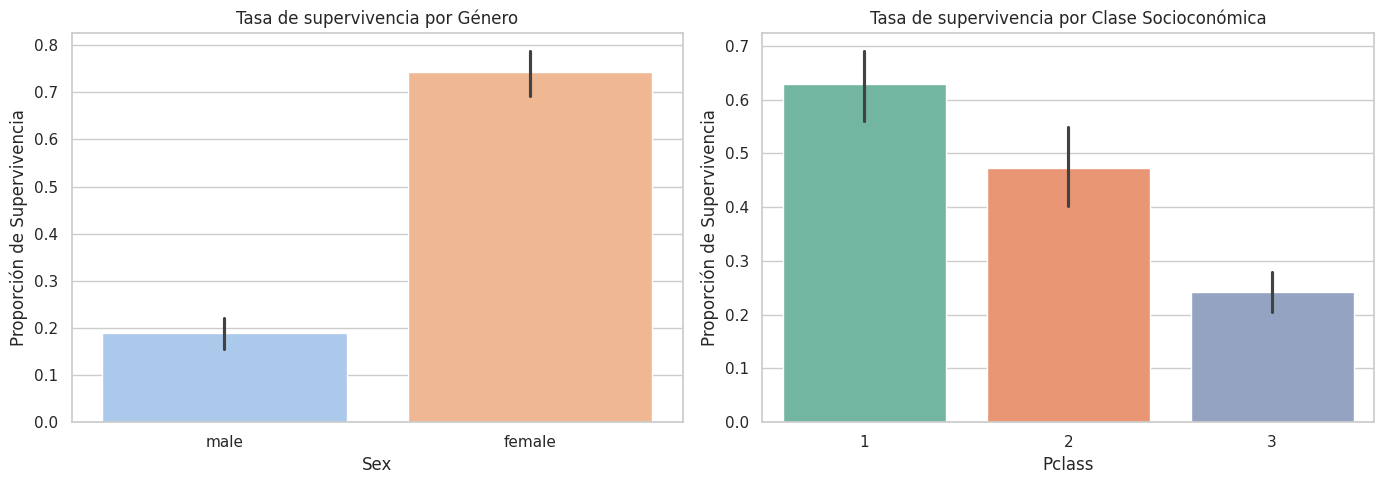

In [ ]:
#Relación de variables con la supervivencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supervivencia por Género
sns.barplot(data=df, x='Sex', y='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('Tasa de supervivencia por Género')
axes[0].set_ylabel('Proporción de Supervivencia')

# Supervivencia por Clase
sns.barplot(data=df, x='Pclass', y='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Tasa de supervivencia por Clase Socioconómica')
axes[1].set_ylabel('Proporción de Supervivencia')

plt.tight_layout()
plt.show()

**Interpretación Bivariada:**
* **Sesgo de género:** A pesar de que los hombres eran mayoría en el barco, la tasa de supervivencia de las mujeres superó el 70%, mientras que la de los hombres fue inferior al 20%. Esto confirma una fuerte asociación estructural.
* **Sesgo de clase:** Se observa una correlación decreciente clara; a menor estrato socioeconómico (Clase 3), menor es la proporción de supervivencia, validando la desigualdad en el desenlace.

### **4.3. Análisis Multivariado**
Evaluamos las correlaciones conjuntas para identificar interacciones complejas.

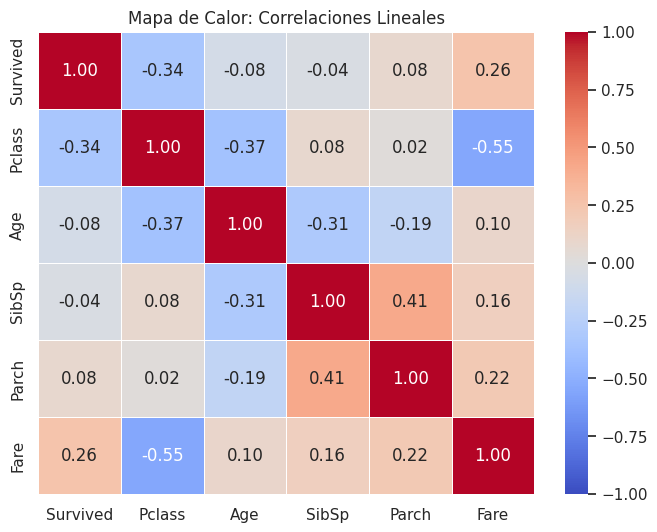

In [ ]:
#Matriz de Correlación
#Seleccionamos solo las variables numéricas clave
columnas_num = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
matriz_corr = df[columnas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlaciones Lineales')
plt.show()

**Interpretación Multivariada:**
* El mapa de calor revela una correlación negativa moderada (-0.34) entre `Pclass` y `Survived`, y una correlación positiva (0.26) con `Fare`. Esto corrobora el sesgo económico.
* Se observa una alta correlación positiva (0.41) entre `SibSp` y `Parch`, lo que indica que las familias tendían a viajar juntas, justificando la futura creación de una variable que consolide el tamaño familiar.


### **4.4. Análisis Multivariado Ampliado: Interacción Género × Clase × Supervivencia**
La siguiente visualización permite explorar simultáneamente tres variables clave para detectar patrones de privilegio diferencial.

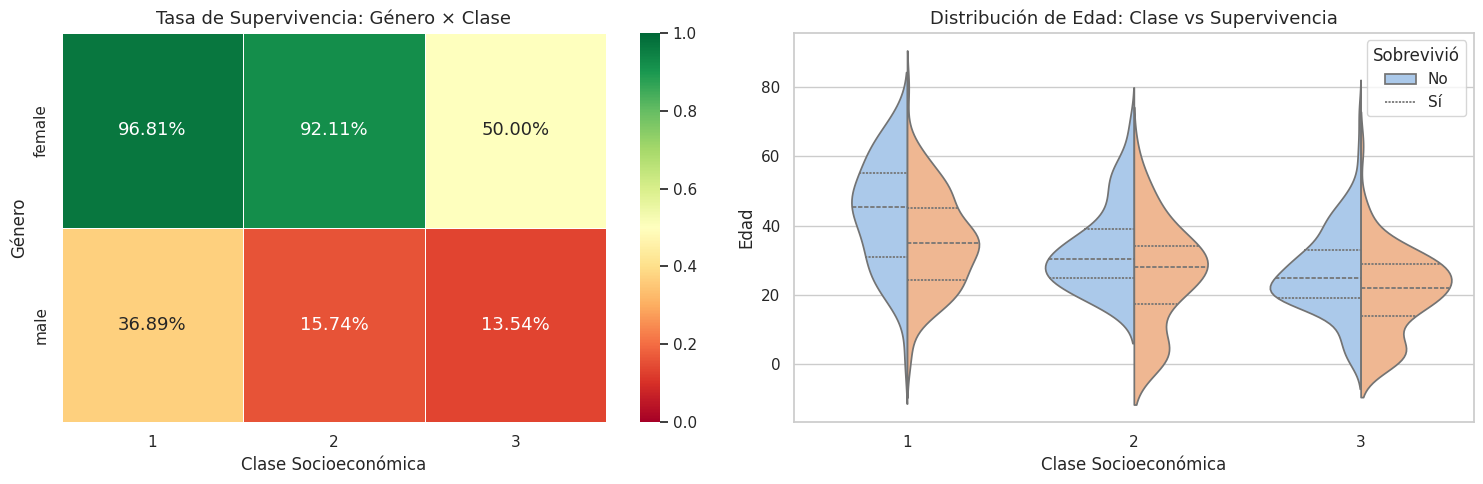

In [ ]:
# Tasa de supervivencia cruzada: Género × Clase
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de supervivencia por Sexo y Clase
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1, annot_kws={"size": 13})
axes[0].set_title('Tasa de Supervivencia: Género × Clase', fontsize=13)
axes[0].set_xlabel('Clase Socioeconómica')
axes[0].set_ylabel('Género')

# Violin plot: Distribución de edad por clase y supervivencia
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived',
               split=True, palette='pastel', ax=axes[1], inner='quart')
axes[1].set_title('Distribución de Edad: Clase vs Supervivencia', fontsize=13)
axes[1].set_xlabel('Clase Socioeconómica')
axes[1].set_ylabel('Edad')
axes[1].legend(title='Sobrevivió', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

**Interpretación:**
- El cruce Género × Clase revela que una **mujer de 3ª clase** tenía mayor tasa de supervivencia (~50%) que un **hombre de 1ª clase** (~37%), confirmando que el género fue el factor determinante por encima del estatus económico.
- El violin plot muestra que en 1ª clase los pasajeros de mayor edad sobrevivieron en mayor proporción, mientras que en 3ª clase la distribución etaria de sobrevivientes y fallecidos es prácticamente idéntica, lo que sugiere que la edad importó menos que la clase en los deciles inferiores.

---

# **5. Detección y tratamiento de Outliers**

Se identificaron anomalías en la variable de tarifas (`Fare`). Utilizaremos métodos visuales para identificar su impacto. Dado que no son errores de digitación, sino representaciones reales de boletos de ultra lujo, aplicar su eliminación representaría una pérdida de información. Optaremos por una transformación matemática para normalizar su varianza.

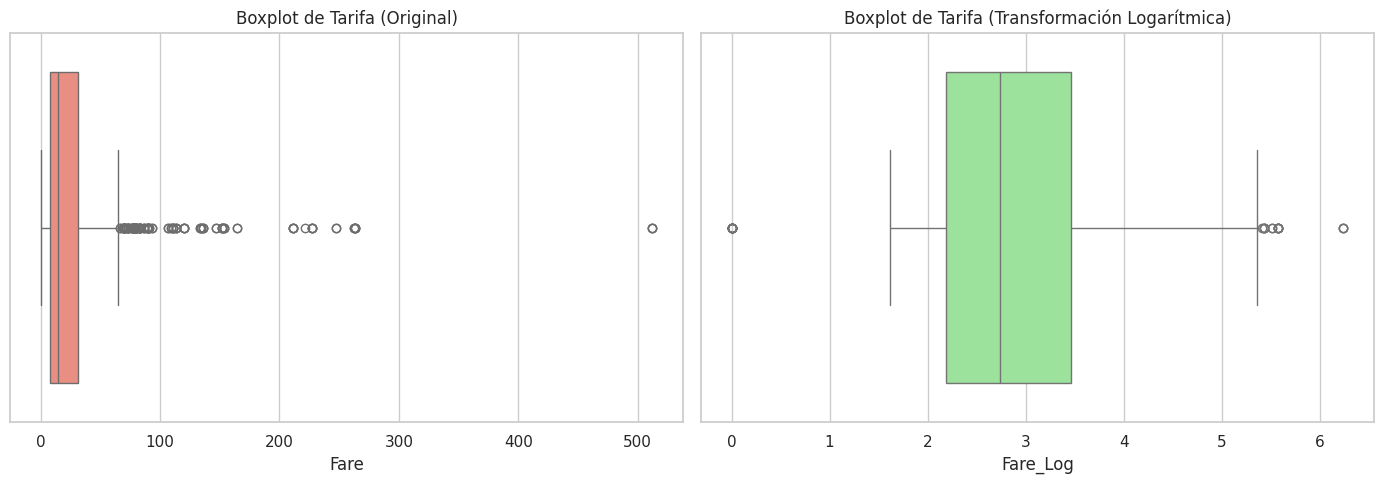

In [ ]:
# --- Método Visual: Boxplots antes y después de transformación ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Fare', color='salmon', ax=axes[0])
axes[0].set_title('Boxplot de Tarifa (Original)')

df['Fare_Log'] = np.log1p(df['Fare'])

sns.boxplot(data=df, x='Fare_Log', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot de Tarifa (Transformación Logarítmica)')  # ← Bug corregido

plt.tight_layout()
plt.show()

In [ ]:
# --- Método Estadístico: Detección por IQR ---
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Fare'] < limite_inferior) | (df['Fare'] > limite_superior)]
print(f"Método IQR — Límite superior: ${limite_superior:.2f}")
print(f"Outliers detectados: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}% del dataset)\n")

# --- Método Estadístico: Detección por Z-Score ---
from scipy import stats
z_scores = np.abs(stats.zscore(df['Fare']))
outliers_zscore = df[z_scores > 3]
print(f"Método Z-Score (|z| > 3) — Outliers detectados: {len(outliers_zscore)}")
print(f"\nTarifas extremas (Top 5):\n{df['Fare'].nlargest(5).to_string()}")

# Resumen comparativo
print("\n" + "─"*40)
print("DECISIÓN: No se eliminan outliers.")
print("Justificación: Las tarifas altas son reales (boletos de lujo).")
print("Tratamiento: Transformación logarítmica (log1p) para normalizar la varianza.")

Método IQR — Límite superior: $65.63
Outliers detectados: 116 (13.0% del dataset)

Método Z-Score (|z| > 3) — Outliers detectados: 20

Tarifas extremas (Top 5):
258    512.3292
679    512.3292
737    512.3292
27     263.0000
88     263.0000

────────────────────────────────────────
DECISIÓN: No se eliminan outliers.
Justificación: Las tarifas altas son reales (boletos de lujo).
Tratamiento: Transformación logarítmica (log1p) para normalizar la varianza.


In [ ]:
# --- Detección de outliers en Age ---
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
outliers_age = df[(df['Age'] < Q1_age - 1.5*IQR_age) | (df['Age'] > Q3_age + 1.5*IQR_age)]
print(f"Outliers en Age (IQR): {len(outliers_age)} registros")
print(f"Rango normal esperado: [{Q1_age - 1.5*IQR_age:.1f}, {Q3_age + 1.5*IQR_age:.1f}] años")
print("Decisión: Se conservan (niños y adultos mayores son pasajeros reales).")

Outliers en Age (IQR): 11 registros
Rango normal esperado: [-6.7, 64.8] años
Decisión: Se conservan (niños y adultos mayores son pasajeros reales).


**Interpretación del tratamiento:**
Al aplicar una transformación logarítmica (`np.log1p`), logramos mitigar la asimetría severa de la tarifa y agrupar la dispersión extrema de los *outliers*. Esto estabiliza la variable, permitiendo que futuros modelos analíticos no se vean sesgados artificialmente por las tarifas exorbitantes de unos pocos pasajeros de primera clase.

## **6. Imputación, escalamiento y transformación de datos**

### **6.1. Imputación de datos faltantes**
* **Variable `Age` (20% nulos):** Para no alterar la distribución demográfica, se rechaza la imputación por la media global. En su lugar, se imputará la edad utilizando la **mediana agrupada por Clase y Sexo**, asumiendo que el estatus social y el género condicionan los perfiles etarios.
* **Variable `Cabin` (77% nulos):** Dada la carencia de información que imposibilita una recuperación estadística confiable, se procede a su eliminación para reducir la dimensionalidad y evitar ruido.
* **Variable `Embarked` (<1% nulos):** Se imputará con el valor más frecuente (moda).

### **6.2. Ingeniería de Características**
A partir de la exploración multivariada, se generará la variable `Family_Size` sumando los hermanos/cónyuges (`SibSp`), padres/hijos (`Parch`) y el propio pasajero (+1). Esto nos permitirá analizar si existe un sesgo hacia las personas que viajaban sin acompañantes.

In [ ]:
# 1. Imputación de 'Age' agrupando por Clase y Sexo
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Imputación de 'Embarked' con la moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Eliminación de la columna 'Cabin'
df.drop('Cabin', axis=1, inplace=True)

# 4. Creación de variable Tamaño de Familia (Family_Size)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Comprobación de nulos y de las nuevas variables
print("Valores nulos restantes:\n", df.isnull().sum())
df[['PassengerId', 'Age', 'Family_Size']].head()

Valores nulos restantes:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Fare_Log       0
Family_Size    0
dtype: int64


,PassengerId,Age,Family_Size
0,1,22.0,2
1,2,38.0,2
2,3,26.0,1
3,4,35.0,2
4,5,35.0,1


### **6.3. Escalamiento de variables numéricas**
Se aplican dos estrategias de escalamiento:
- **StandardScaler** sobre `Age`: normaliza hacia media 0 y desviación estándar 1, respetando la distribución aproximadamente normal.
- **MinMaxScaler** sobre `Fare_Log`: comprime el rango a [0, 1], apropiado dado que ya fue transformada logarítmicamente.

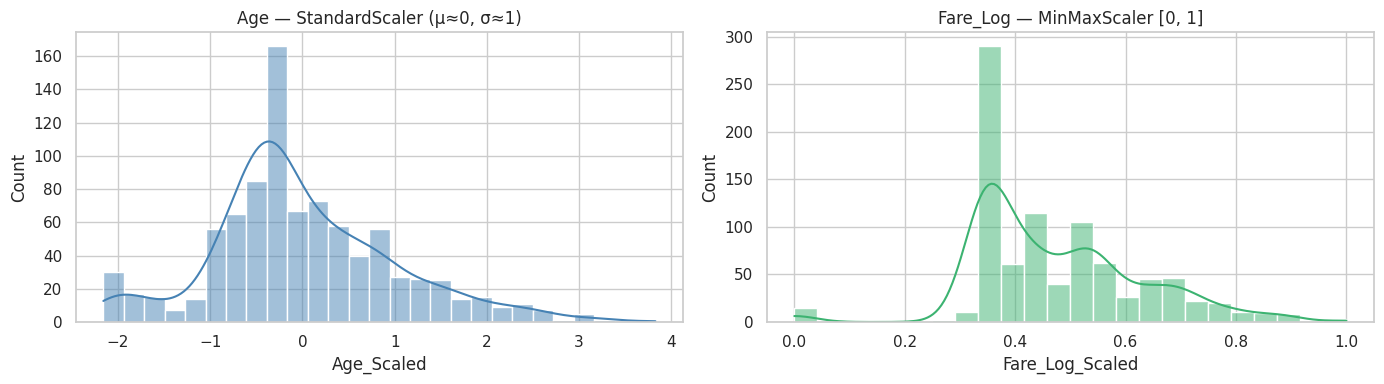

Estadísticas de Age escalada:      media= 0.0  | std= 1.0006
Estadísticas de Fare_Log escalada: min= 0.0  | max= 1.0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

df['Age_Scaled']      = scaler_std.fit_transform(df[['Age']])
df['Fare_Log_Scaled'] = scaler_mm.fit_transform(df[['Fare_Log']])

# Verificación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Age_Scaled'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age — StandardScaler (μ≈0, σ≈1)')

sns.histplot(df['Fare_Log_Scaled'], kde=True, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Fare_Log — MinMaxScaler [0, 1]')

plt.tight_layout()
plt.show()

print("Estadísticas de Age escalada:      media=", round(df['Age_Scaled'].mean(), 4),
      " | std=", round(df['Age_Scaled'].std(), 4))
print("Estadísticas de Fare_Log escalada: min=",  round(df['Fare_Log_Scaled'].min(), 4),
      " | max=", round(df['Fare_Log_Scaled'].max(), 4))

### **6.4. Codificación de variables categóricas**
Se aplica codificación binaria (`LabelEncoder`) a `Sex` y codificación *one-hot* (`get_dummies`) a `Embarked`, preparando el dataset para su uso en modelos analíticos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])  # female=0, male=1

# One-Hot Encoding para Embarked
# Solo aplicar si la columna 'Embarked' todavía existe en el DataFrame
if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb', drop_first=True)
else:
    print("La columna 'Embarked' ya ha sido codificada o no existe.")

print("Variables añadidas al dataset:")
nuevas_vars = ['Sex_Encoded', 'Emb_Q', 'Emb_S', 'Family_Size',
               'Age_Scaled', 'Fare_Log', 'Fare_Log_Scaled']
print(df[nuevas_vars].head())
print(f"\nShape final del dataset: {df.shape}")

La columna 'Embarked' ya ha sido codificada o no existe.
Variables añadidas al dataset:
   Sex_Encoded  Emb_Q  Emb_S  Family_Size  Age_Scaled  Fare_Log  \
0            1  False   True            2   -0.534891  2.110213   
1            0  False  False            2    0.668392  4.280593   
2            0  False   True            1   -0.234070  2.188856   
3            0  False   True            2    0.442776  3.990834   
4            1  False   True            1    0.442776  2.202765   

   Fare_Log_Scaled  
0         0.338125  
1         0.685892  
2         0.350727  
3         0.639463  
4         0.352955  

Shape final del dataset: (891, 17)


## **7. Resultados e Interpretación**

/tmp/ipykernel_19495/2359749119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Family_Size', y='Survived', palette='viridis', errorbar=None)


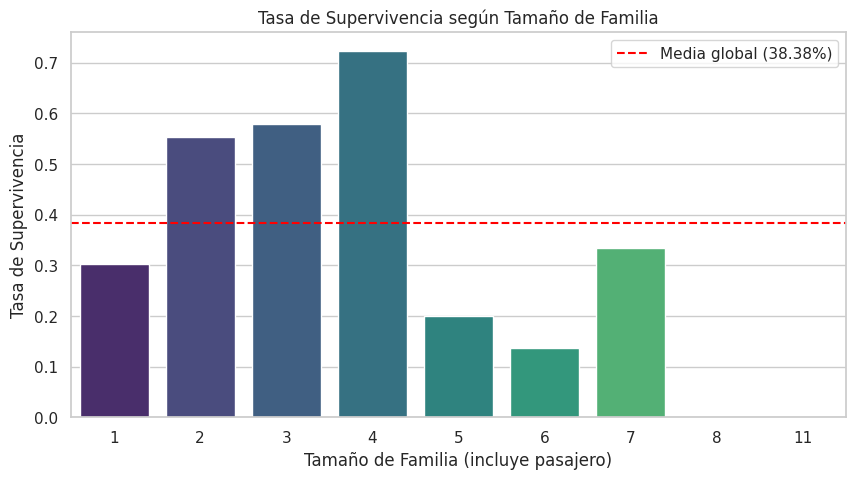

In [ ]:
# --- Resultado 1: Supervivencia por Tamaño de Familia ---
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Family_Size', y='Survived', palette='viridis', errorbar=None)
plt.title('Tasa de Supervivencia según Tamaño de Familia')
plt.xlabel('Tamaño de Familia (incluye pasajero)')
plt.ylabel('Tasa de Supervivencia')
plt.axhline(y=df['Survived'].mean(), color='red', linestyle='--', label=f"Media global ({df['Survived'].mean():.2%})")
plt.legend()
plt.show()

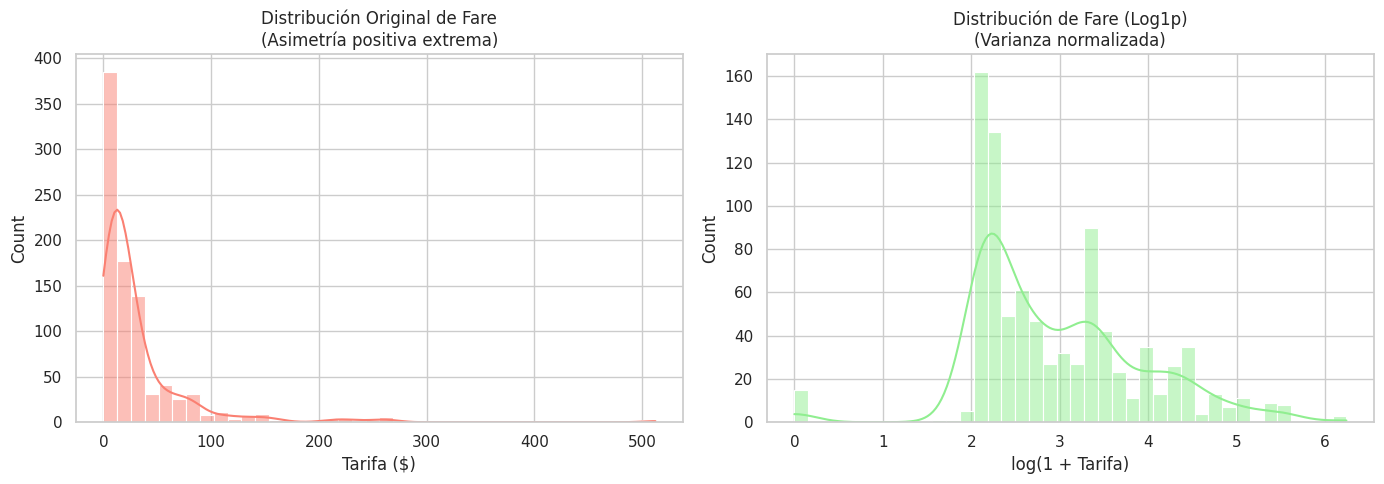

Asimetría (skewness) Fare original: 4.787
Asimetría (skewness) Fare_Log:      0.395


In [ ]:
# --- Resultado 2: Comparación Fare antes/después de transformación ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Fare'], kde=True, color='salmon', ax=axes[0], bins=40)
axes[0].set_title('Distribución Original de Fare\n(Asimetría positiva extrema)')
axes[0].set_xlabel('Tarifa ($)')

sns.histplot(df['Fare_Log'], kde=True, color='lightgreen', ax=axes[1], bins=40)
axes[1].set_title('Distribución de Fare (Log1p)\n(Varianza normalizada)')
axes[1].set_xlabel('log(1 + Tarifa)')

plt.tight_layout()
plt.show()

print(f"Asimetría (skewness) Fare original: {df['Fare'].skew():.3f}")
print(f"Asimetría (skewness) Fare_Log:      {df['Fare_Log'].skew():.3f}")

In [ ]:
# --- Resultado 3: Tabla resumen de tasas de supervivencia ---
print("═"*55)
print("RESUMEN DE TASAS DE SUPERVIVENCIA POR SUBGRUPO")
print("═"*55)

resumen = {
    'Mujeres':           df[df['Sex']=='female']['Survived'].mean(),
    'Hombres':           df[df['Sex']=='male']['Survived'].mean(),
    'Clase 1':           df[df['Pclass']==1]['Survived'].mean(),
    'Clase 2':           df[df['Pclass']==2]['Survived'].mean(),
    'Clase 3':           df[df['Pclass']==3]['Survived'].mean(),
    'Viajero solo':      df[df['Family_Size']==1]['Survived'].mean(),
    'Familia mediana (2-4)': df[df['Family_Size'].between(2,4)]['Survived'].mean(),
    'Familia grande (5+)':   df[df['Family_Size']>=5]['Survived'].mean(),
}

for grupo, tasa in resumen.items():
    barra = '█' * int(tasa * 30)
    print(f"  {grupo:<25} {tasa:.1%}  {barra}")

═══════════════════════════════════════════════════════
RESUMEN DE TASAS DE SUPERVIVENCIA POR SUBGRUPO
═══════════════════════════════════════════════════════
  Mujeres                   74.2%  ██████████████████████
  Hombres                   18.9%  █████
  Clase 1                   63.0%  ██████████████████
  Clase 2                   47.3%  ██████████████
  Clase 3                   24.2%  ███████
  Viajero solo              30.4%  █████████
  Familia mediana (2-4)     57.9%  █████████████████
  Familia grande (5+)       16.1%  ████


## **8. Conclusiones**

El presente análisis exploratorio y de transformación de datos proporciona evidencia estadística suficiente para responder afirmativamente a la pregunta de investigación. Se identificó la existencia de marcados **sesgos sociodemográficos y económicos** fuertemente asociados a la supervivencia de los pasajeros del Titanic:

1. **Sesgo de Género y Edad:** La priorización de evacuación no fue un mito histórico, sino un patrón estadístico innegable en los datos. El género femenino representó el mayor predictor aislado de supervivencia.
2. **Desigualdad Estructural (Clase y Tarifa):** Se demostró que la mortalidad estuvo concentrada asimétricamente en el estrato socioeconómico más bajo (Clase 3). La normalización matemática de la variable económica (`Fare_Log`) y su cruce con la clase corroboran que el poder adquisitivo facilitó el acceso diferencial a la seguridad.
3. **El Factor Familiar:** Mediante la ingeniería de características se logró evidenciar que el aislamiento social a bordo (viajar solo) actuó como un factor de riesgo crítico, mientras que pertenecer a un núcleo familiar moderado funcionó como una ventaja logística al momento de la supervivencia.

Este estudio demuestra cómo la adecuada preparación, transformación y exploración de los datos permite extraer realidades sociológicas ocultas en variables en bruto, garantizando un análisis objetivo y profesional exento de sesgos narrativos.